In [1]:
from google.colab import files
uploaded = files.upload()

Saving crop_yield_dataset.csv to crop_yield_dataset.csv


In [3]:
import pandas as pd
df = pd.read_csv("crop_yield_dataset.csv")
print("Shape:", df.shape)
print(df.columns.tolist())
df.head()


Shape: (10000, 13)
['Crop', 'Region', 'Soil_Type', 'Soil_pH', 'Rainfall_mm', 'Temperature_C', 'Humidity_pct', 'Fertilizer_Used_kg', 'Irrigation', 'Pesticides_Used_kg', 'Planting_Density', 'Previous_Crop', 'Yield_ton_per_ha']


,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,NaN,169.06
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71


In [4]:
df.isnull().sum()

,0
Crop,0
Region,0
Soil_Type,0
Soil_pH,0
Rainfall_mm,0
Temperature_C,0
Humidity_pct,0
Fertilizer_Used_kg,0
Irrigation,2538
Pesticides_Used_kg,0


In [5]:
df['Previous_Crop'].fillna('Unknown', inplace=True)
df['Irrigation'].fillna('Unknown', inplace=True)

/tmp/ipykernel_1043/4273105339.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Previous_Crop'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1043/4273105339.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [6]:
df.isnull().sum()

,0
Crop,0
Region,0
Soil_Type,0
Soil_pH,0
Rainfall_mm,0
Temperature_C,0
Humidity_pct,0
Fertilizer_Used_kg,0
Irrigation,0
Pesticides_Used_kg,0


In [7]:
X = df.drop('Yield_ton_per_ha', axis=1)
y = df['Yield_ton_per_ha']

In [8]:
categorical_cols = [
    'Crop',
    'Region',
    'Soil_Type',
    'Irrigation',
    'Previous_Crop'
]

numerical_cols = [
    'Soil_pH',
    'Rainfall_mm',
    'Temperature_C',
    'Humidity_pct',
    'Fertilizer_Used_kg',
    'Pesticides_Used_kg',
    'Planting_Density'
]

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

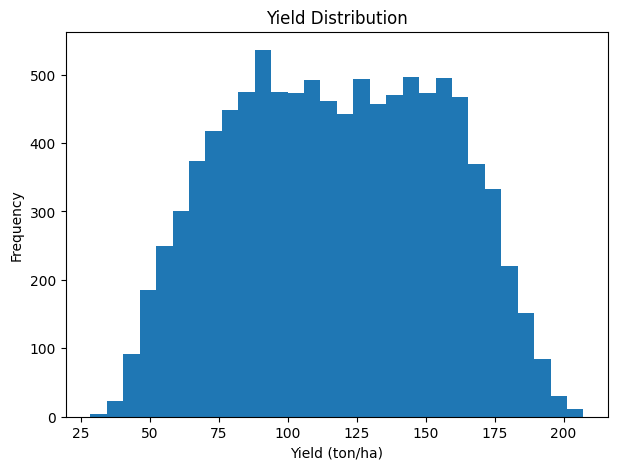

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(df['Yield_ton_per_ha'], bins=30)
plt.title("Yield Distribution")
plt.xlabel("Yield (ton/ha)")
plt.ylabel("Frequency")
plt.show()

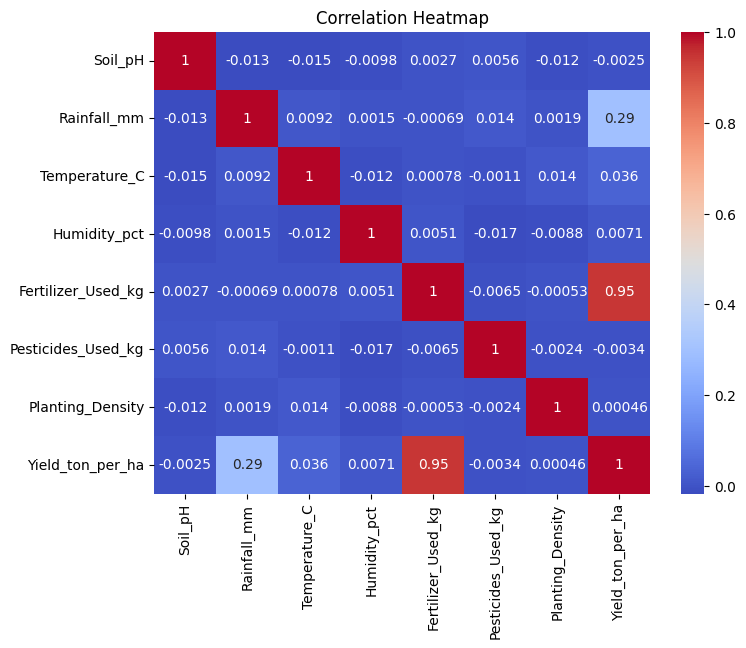

In [12]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df[numerical_cols + ['Yield_ton_per_ha']].corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()

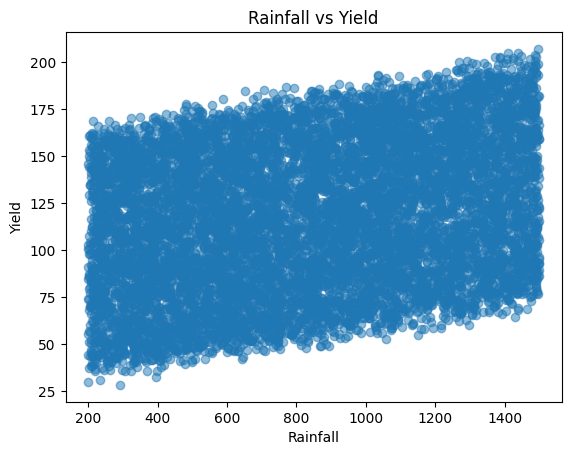

In [13]:
plt.scatter(df['Rainfall_mm'], df['Yield_ton_per_ha'], alpha=0.5)
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

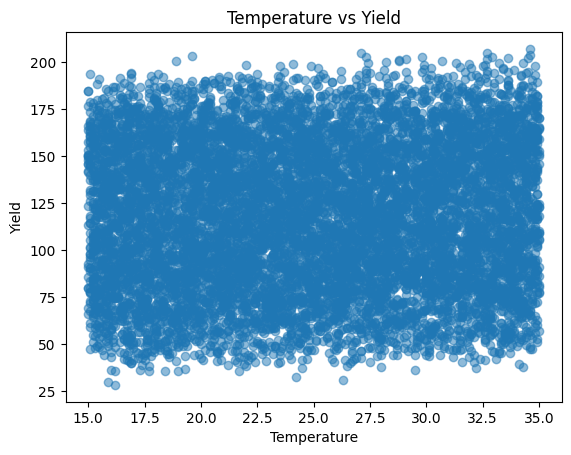

In [14]:
plt.scatter(df['Temperature_C'], df['Yield_ton_per_ha'], alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Yield")
plt.title("Temperature vs Yield")
plt.show()

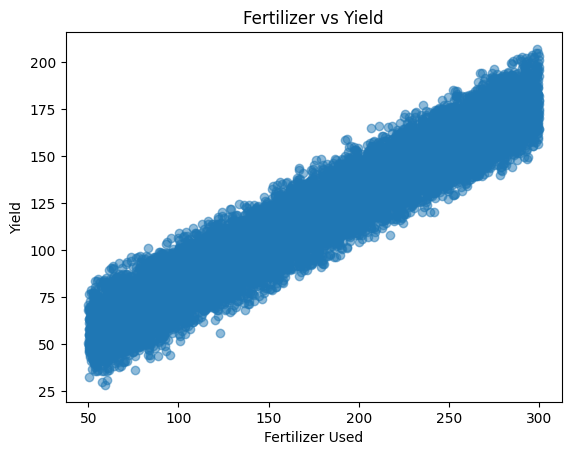

In [15]:
plt.scatter(df['Fertilizer_Used_kg'], df['Yield_ton_per_ha'], alpha=0.5)
plt.xlabel("Fertilizer Used")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()

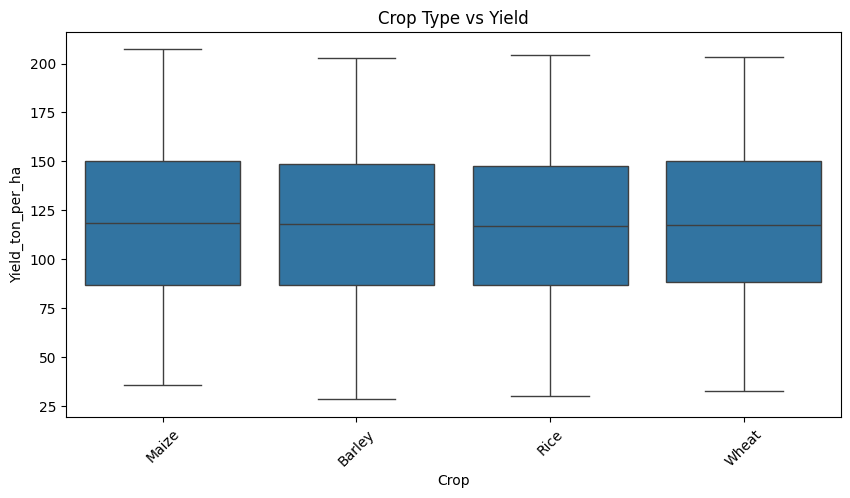

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Crop', y='Yield_ton_per_ha', data=df)
plt.xticks(rotation=45)
plt.title("Crop Type vs Yield")
plt.show()

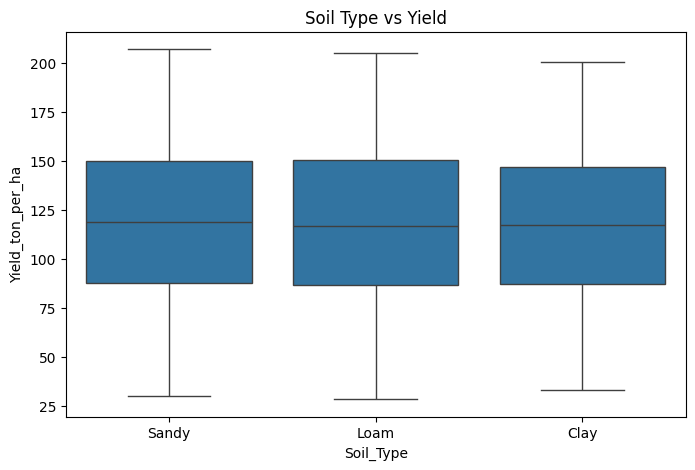

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Soil_Type', y='Yield_ton_per_ha', data=df)
plt.title("Soil Type vs Yield")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results:
MAE: 4.274377779147168
MSE: 28.295950312084745
RMSE: 5.31939379178537
R2 Score: 0.9804043584529575


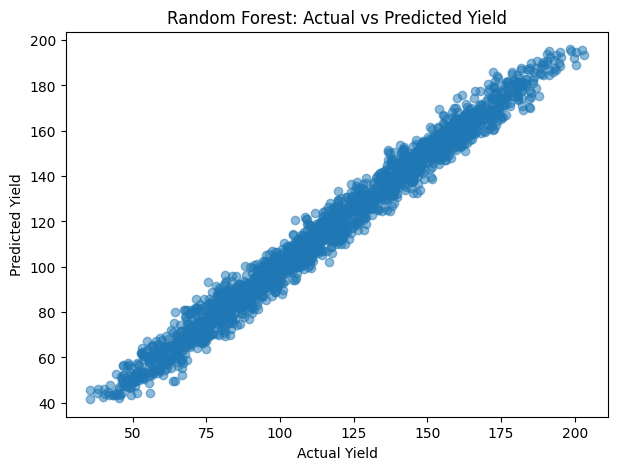

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted Yield")
plt.show()

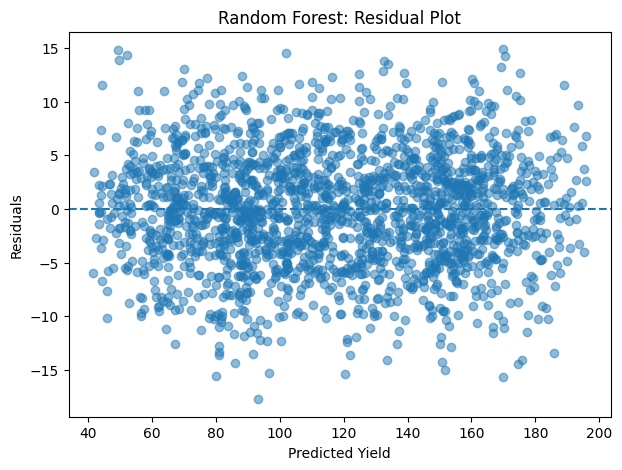

In [20]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(7, 5))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")
plt.show()

In [21]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

XGBoost Results:
MAE: 4.2874330768585205
RMSE: 5.3121681998973775
R2 Score: 0.9804575577270731


In [22]:
from sklearn.neural_network import MLPRegressor

mlp_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=300,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Results:")
print("MAE:", mae_mlp)
print("RMSE:", rmse_mlp)
print("R2 Score:", r2_mlp)

MLP Results:
MAE: 4.671651210930714
RMSE: 5.836752186628116
R2 Score: 0.976407296393993


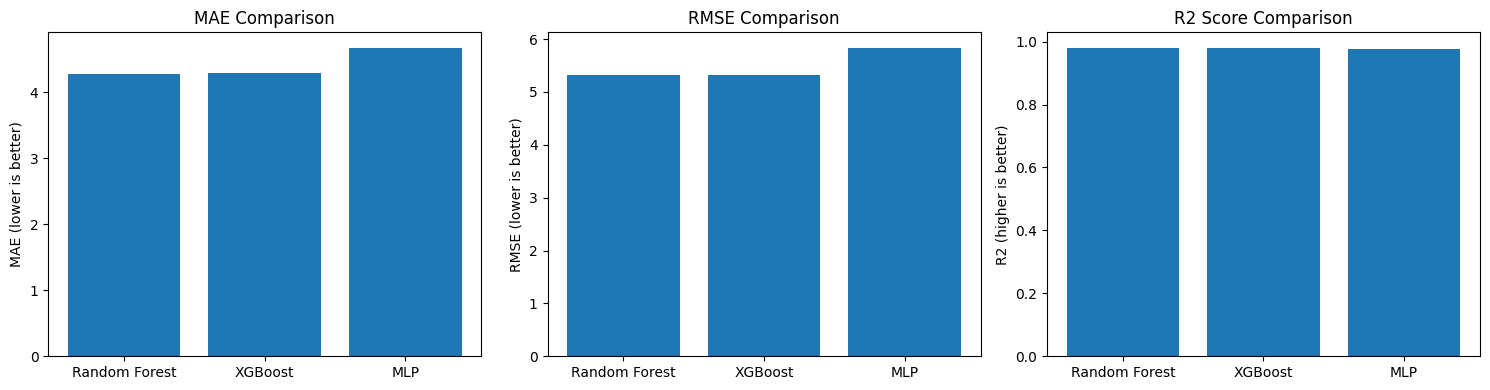

In [23]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'XGBoost', 'MLP']

mae = [mae_rf, mae_xgb, mae_mlp]
rmse = [rmse_rf, rmse_xgb, rmse_mlp]
r2 = [r2_rf, r2_xgb, r2_mlp]

# Create subplots
plt.figure(figsize=(15,4))

# MAE
plt.subplot(1,3,1)
plt.bar(models, mae)
plt.title("MAE Comparison")
plt.ylabel("MAE (lower is better)")

# RMSE
plt.subplot(1,3,2)
plt.bar(models, rmse)
plt.title("RMSE Comparison")
plt.ylabel("RMSE (lower is better)")

# R2 Score
plt.subplot(1,3,3)
plt.bar(models, r2)
plt.title("R2 Score Comparison")
plt.ylabel("R2 (higher is better)")

plt.tight_layout()
plt.show()

In [24]:
import joblib

joblib.dump(xgb_model, "yield_model.pkl")

['yield_model.pkl']

In [25]:
from google.colab import files
files.download("yield_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>